Available bathymetry items:
0 
Selected timestep with reef: 2017-08-26T02:30:00.000000000
Selected timestep without reef: 2017-08-26T02:30:00.000000000


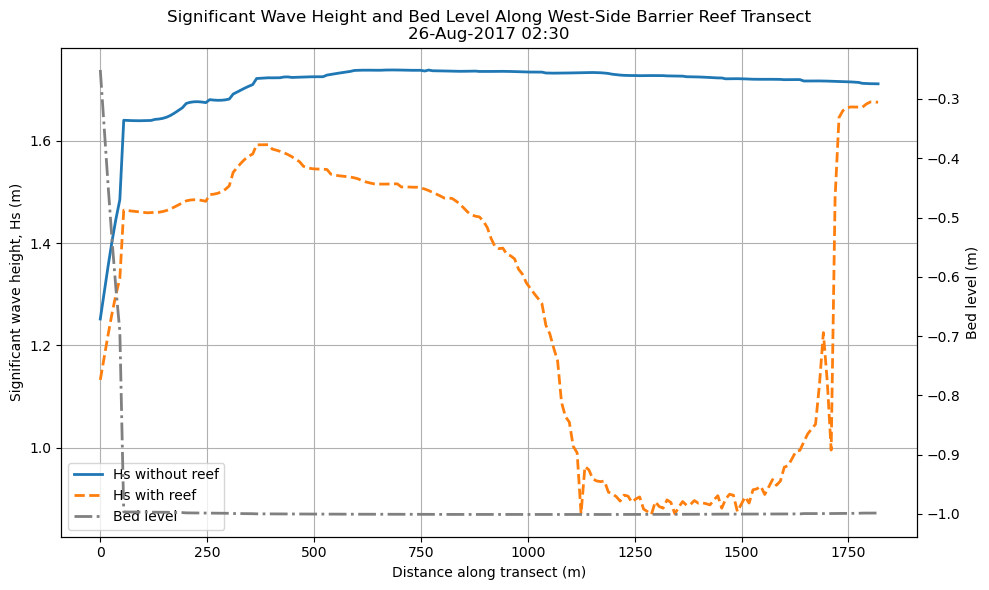

In [6]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# With reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# Bathymetry DFSU file
bathy_dfsu = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\existing_topo_bathy_port_lavaca.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Target time
# =========================
target_time = np.datetime64("2017-08-26T02:30:00")


# =========================
# Extract DFSU profile
# =========================
def extract_dfsu_profile(dfsu_file, item_name, target_time=None):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    da = ds[item_name]

    if "time" in da.dims and target_time is not None:
        time_index = np.argmin(np.abs(ds.time.values - target_time))
        selected_time = ds.time.values[time_index]
        da = da.isel(time=time_index)
    else:
        selected_time = None
        if "time" in da.dims:
            da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time


# =========================
# Extract bed level from bathymetry DFSU
# =========================
def extract_bed_from_dfsu(dfsu_file, item=0):
    dfs = mikeio.open(dfsu_file)

    print("Available bathymetry items:")
    for i, itm in enumerate(dfs.items):
        print(i, itm.name)

    ds = dfs.read(items=[item])
    da = ds[0]

    if "time" in da.dims:
        da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    bed_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return bed_profile


# =========================
# Extract variables
# =========================

hs_reef, time_reef = extract_dfsu_profile(
    dfsu_reef,
    "Sign. Wave Height",
    target_time
)

hs_no_reef, time_no_reef = extract_dfsu_profile(
    dfsu_no_reef,
    "Sign. Wave Height",
    target_time
)

bed_level = extract_bed_from_dfsu(
    bathy_dfsu,
    item=0
)

print("Selected timestep with reef:", time_reef)
print("Selected timestep without reef:", time_no_reef)


# =========================
# Plot
# =========================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary y-axis: Significant wave height
ax1.plot(
    distance,
    hs_no_reef,
    linewidth=2,
    label="Hs without reef"
)

ax1.plot(
    distance,
    hs_reef,
    linewidth=2,
    linestyle="--",
    label="Hs with reef"
)

ax1.set_xlabel("Distance along transect (m)")
ax1.set_ylabel("Significant wave height, Hs (m)")
ax1.grid(True)

# Secondary y-axis: Bed level
ax2 = ax1.twinx()

ax2.plot(
    distance,
    bed_level,
    linewidth=2,
    color="gray",
    linestyle="-.",
    label="Bed level"
)

ax2.set_ylabel("Bed level (m)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

plt.title(
    "Significant Wave Height and Bed Level Along West-Side Barrier Reef Transect\n"
    "26-Aug-2017 02:30"
)

plt.tight_layout()
plt.show()

Available bathymetry items:
0 
Selected timestep with reef: 2017-08-26T02:30:00.000000000
Selected timestep without reef: 2017-08-26T02:30:00.000000000


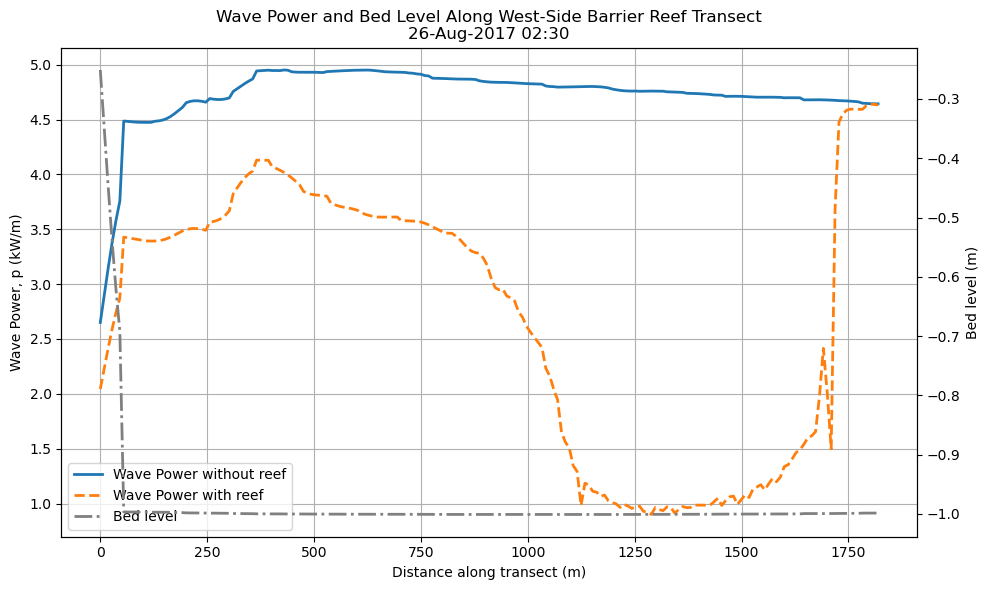

In [7]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# With reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# Bathymetry DFSU file
bathy_dfsu = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\existing_topo_bathy_port_lavaca.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Target time
# =========================
target_time = np.datetime64("2017-08-26T02:30:00")


# =========================
# Extract DFSU profile
# =========================
def extract_dfsu_profile(dfsu_file, item_name, target_time=None):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    da = ds[item_name]

    if "time" in da.dims and target_time is not None:
        time_index = np.argmin(np.abs(ds.time.values - target_time))
        selected_time = ds.time.values[time_index]
        da = da.isel(time=time_index)
    else:
        selected_time = None
        if "time" in da.dims:
            da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time


# =========================
# Extract bed level from bathymetry DFSU
# =========================
def extract_bed_from_dfsu(dfsu_file, item=0):
    dfs = mikeio.open(dfsu_file)

    print("Available bathymetry items:")
    for i, itm in enumerate(dfs.items):
        print(i, itm.name)

    ds = dfs.read(items=[item])
    da = ds[0]

    if "time" in da.dims:
        da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    bed_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return bed_profile


# =========================
# Extract variables
# =========================

hs_reef, time_reef = extract_dfsu_profile(
    dfsu_reef,
    "Wave power, p",
    target_time
)

hs_no_reef, time_no_reef = extract_dfsu_profile(
    dfsu_no_reef,
    "Wave power, p",
    target_time
)

bed_level = extract_bed_from_dfsu(
    bathy_dfsu,
    item=0
)

print("Selected timestep with reef:", time_reef)
print("Selected timestep without reef:", time_no_reef)


# =========================
# Plot
# =========================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary y-axis: Significant wave height
ax1.plot(
    distance,
    hs_no_reef,
    linewidth=2,
    label="Wave Power without reef"
)

ax1.plot(
    distance,
    hs_reef,
    linewidth=2,
    linestyle="--",
    label="Wave Power with reef"
)

ax1.set_xlabel("Distance along transect (m)")
ax1.set_ylabel("Wave Power, p (kW/m)")
ax1.grid(True)

# Secondary y-axis: Bed level
ax2 = ax1.twinx()

ax2.plot(
    distance,
    bed_level,
    linewidth=2,
    color="gray",
    linestyle="-.",
    label="Bed level"
)

ax2.set_ylabel("Bed level (m)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

plt.title(
    "Wave Power and Bed Level Along West-Side Barrier Reef Transect\n"
    "26-Aug-2017 02:30"
)

plt.tight_layout()
plt.show()

Available bathymetry items:
0 
Selected timestep with reef: 2017-08-26T02:30:00.000000000
Selected timestep without reef: 2017-08-26T02:30:00.000000000


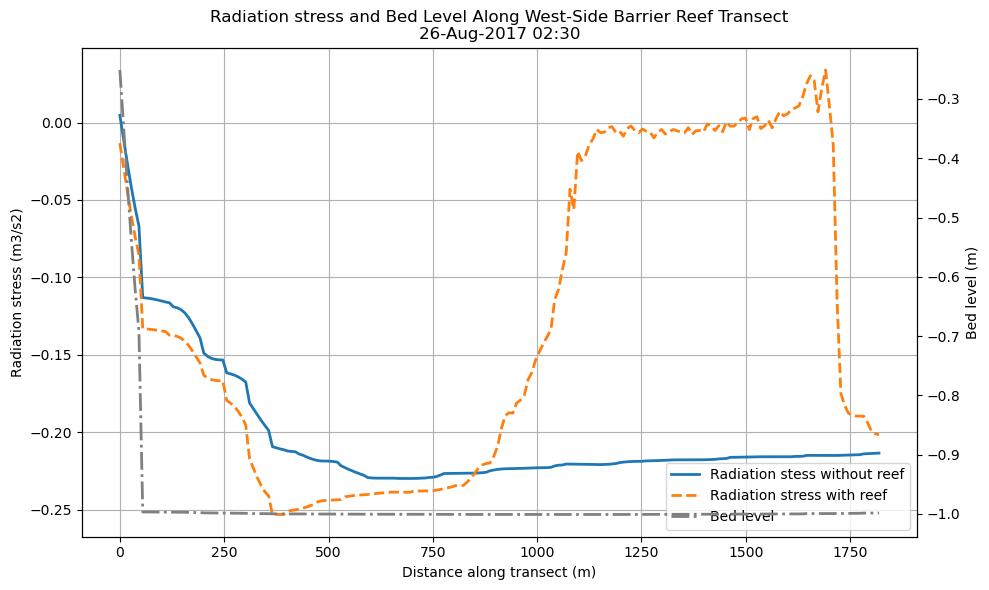

In [9]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# With reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# Bathymetry DFSU file
bathy_dfsu = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\existing_topo_bathy_port_lavaca.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Target time
# =========================
target_time = np.datetime64("2017-08-26T02:30:00")


# =========================
# Extract DFSU profile
# =========================
def extract_dfsu_profile(dfsu_file, item_name, target_time=None):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    da = ds[item_name]

    if "time" in da.dims and target_time is not None:
        time_index = np.argmin(np.abs(ds.time.values - target_time))
        selected_time = ds.time.values[time_index]
        da = da.isel(time=time_index)
    else:
        selected_time = None
        if "time" in da.dims:
            da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time


# =========================
# Extract bed level from bathymetry DFSU
# =========================
def extract_bed_from_dfsu(dfsu_file, item=0):
    dfs = mikeio.open(dfsu_file)

    print("Available bathymetry items:")
    for i, itm in enumerate(dfs.items):
        print(i, itm.name)

    ds = dfs.read(items=[item])
    da = ds[0]

    if "time" in da.dims:
        da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    bed_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return bed_profile


# =========================
# Extract variables
# =========================

hs_reef, time_reef = extract_dfsu_profile(
    dfsu_reef,
    "Rad. Stress, Sxy",
    target_time
)

hs_no_reef, time_no_reef = extract_dfsu_profile(
    dfsu_no_reef,
    "Rad. Stress, Sxy",
    target_time
)

bed_level = extract_bed_from_dfsu(
    bathy_dfsu,
    item=0
)

print("Selected timestep with reef:", time_reef)
print("Selected timestep without reef:", time_no_reef)


# =========================
# Plot
# =========================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary y-axis: Significant wave height
ax1.plot(
    distance,
    hs_no_reef,
    linewidth=2,
    label="Radiation stess without reef"
)

ax1.plot(
    distance,
    hs_reef,
    linewidth=2,
    linestyle="--",
    label="Radiation stress with reef"
)

ax1.set_xlabel("Distance along transect (m)")
ax1.set_ylabel("Radiation stress (m3/s2)")
ax1.grid(True)

# Secondary y-axis: Bed level
ax2 = ax1.twinx()

ax2.plot(
    distance,
    bed_level,
    linewidth=2,
    color="gray",
    linestyle="-.",
    label="Bed level"
)

ax2.set_ylabel("Bed level (m)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

plt.title(
    "Radiation stress and Bed Level Along West-Side Barrier Reef Transect\n"
    "26-Aug-2017 02:30"
)

plt.tight_layout()
plt.show()

Available bathymetry items:
0 
Selected timestep with reef: 2017-08-26T02:30:00.000000000
Selected timestep without reef: 2017-08-26T02:30:00.000000000


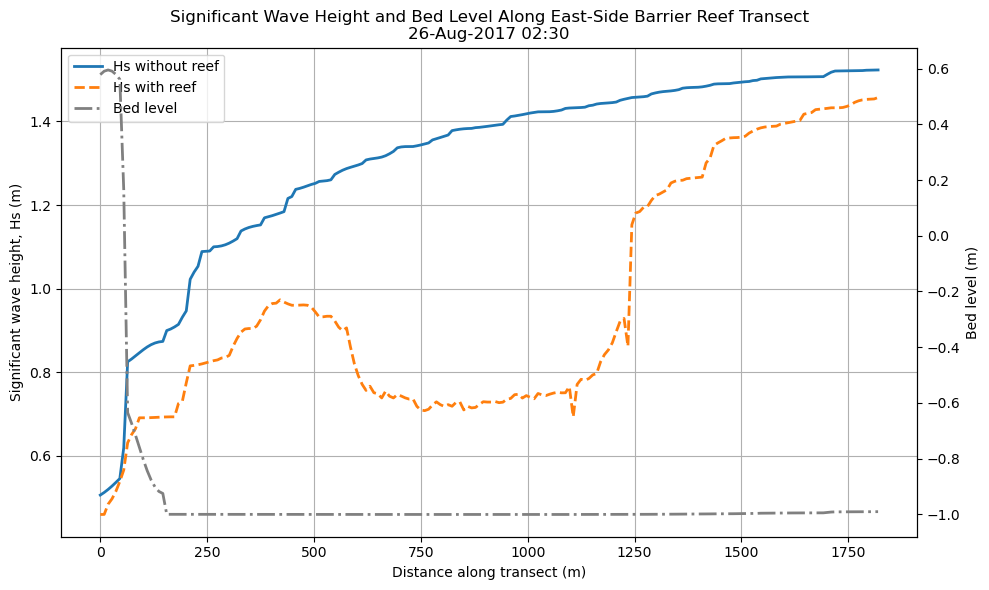

In [16]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# With reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef.sw - Result Files\east_side_reef.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# Bathymetry DFSU file
bathy_dfsu = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\existing_topo_bathy_port_lavaca.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 736598, 3177013
x2, y2 = 734987, 3176167

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Target time
# =========================
target_time = np.datetime64("2017-08-26T02:30:00")


# =========================
# Extract DFSU profile
# =========================
def extract_dfsu_profile(dfsu_file, item_name, target_time=None):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    da = ds[item_name]

    if "time" in da.dims and target_time is not None:
        time_index = np.argmin(np.abs(ds.time.values - target_time))
        selected_time = ds.time.values[time_index]
        da = da.isel(time=time_index)
    else:
        selected_time = None
        if "time" in da.dims:
            da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time


# =========================
# Extract bed level from bathymetry DFSU
# =========================
def extract_bed_from_dfsu(dfsu_file, item=0):
    dfs = mikeio.open(dfsu_file)

    print("Available bathymetry items:")
    for i, itm in enumerate(dfs.items):
        print(i, itm.name)

    ds = dfs.read(items=[item])
    da = ds[0]

    if "time" in da.dims:
        da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    bed_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return bed_profile


# =========================
# Extract variables
# =========================

hs_reef, time_reef = extract_dfsu_profile(
    dfsu_reef,
    "Sign. Wave Height",
    target_time
)

hs_no_reef, time_no_reef = extract_dfsu_profile(
    dfsu_no_reef,
    "Sign. Wave Height",
    target_time
)

bed_level = extract_bed_from_dfsu(
    bathy_dfsu,
    item=0
)

print("Selected timestep with reef:", time_reef)
print("Selected timestep without reef:", time_no_reef)


# =========================
# Plot
# =========================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary y-axis: Significant wave height
ax1.plot(
    distance,
    hs_no_reef,
    linewidth=2,
    label="Hs without reef"
)

ax1.plot(
    distance,
    hs_reef,
    linewidth=2,
    linestyle="--",
    label="Hs with reef"
)

ax1.set_xlabel("Distance along transect (m)")
ax1.set_ylabel("Significant wave height, Hs (m)")
ax1.grid(True)

# Secondary y-axis: Bed level
ax2 = ax1.twinx()

ax2.plot(
    distance,
    bed_level,
    linewidth=2,
    color="gray",
    linestyle="-.",
    label="Bed level"
)

ax2.set_ylabel("Bed level (m)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

plt.title(
    "Significant Wave Height and Bed Level Along East-Side Barrier Reef Transect\n"
    "26-Aug-2017 02:30"
)

plt.tight_layout()
plt.show()

Available bathymetry items:
0 
Selected timestep with reef: 2017-08-26T02:30:00.000000000
Selected timestep without reef: 2017-08-26T02:30:00.000000000


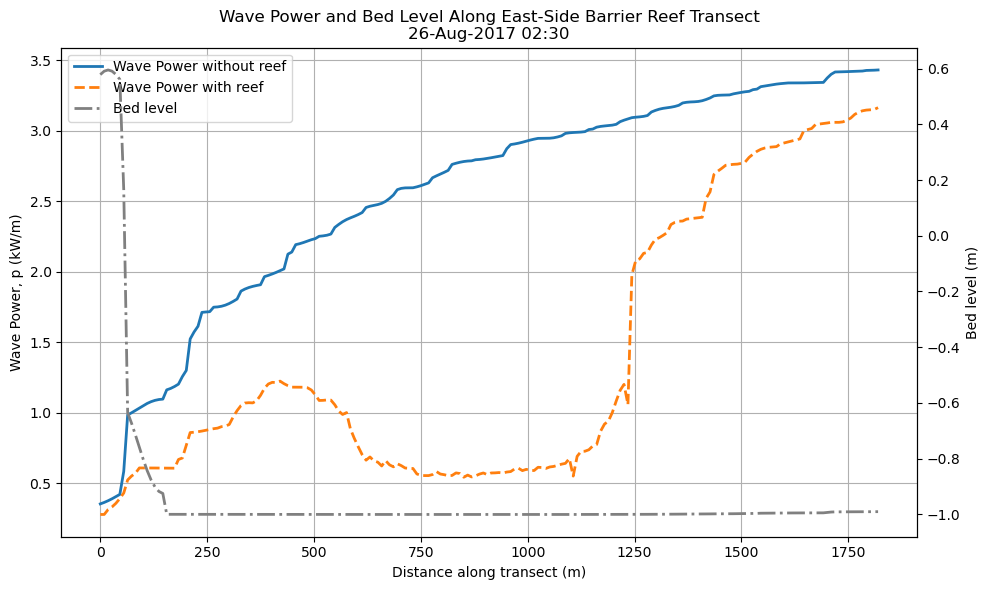

In [15]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# With reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef.sw - Result Files\east_side_reef.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# Bathymetry DFSU file
bathy_dfsu = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\existing_topo_bathy_port_lavaca.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 736598, 3177013
x2, y2 = 734987, 3176167

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Target time
# =========================
target_time = np.datetime64("2017-08-26T02:30:00")


# =========================
# Extract DFSU profile
# =========================
def extract_dfsu_profile(dfsu_file, item_name, target_time=None):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    da = ds[item_name]

    if "time" in da.dims and target_time is not None:
        time_index = np.argmin(np.abs(ds.time.values - target_time))
        selected_time = ds.time.values[time_index]
        da = da.isel(time=time_index)
    else:
        selected_time = None
        if "time" in da.dims:
            da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time


# =========================
# Extract bed level from bathymetry DFSU
# =========================
def extract_bed_from_dfsu(dfsu_file, item=0):
    dfs = mikeio.open(dfsu_file)

    print("Available bathymetry items:")
    for i, itm in enumerate(dfs.items):
        print(i, itm.name)

    ds = dfs.read(items=[item])
    da = ds[0]

    if "time" in da.dims:
        da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    bed_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return bed_profile


# =========================
# Extract variables
# =========================

hs_reef, time_reef = extract_dfsu_profile(
    dfsu_reef,
    "Wave power, p",
    target_time
)

hs_no_reef, time_no_reef = extract_dfsu_profile(
    dfsu_no_reef,
    "Wave power, p",
    target_time
)

bed_level = extract_bed_from_dfsu(
    bathy_dfsu,
    item=0
)

print("Selected timestep with reef:", time_reef)
print("Selected timestep without reef:", time_no_reef)


# =========================
# Plot
# =========================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary y-axis: Significant wave height
ax1.plot(
    distance,
    hs_no_reef,
    linewidth=2,
    label="Wave Power without reef"
)

ax1.plot(
    distance,
    hs_reef,
    linewidth=2,
    linestyle="--",
    label="Wave Power with reef"
)

ax1.set_xlabel("Distance along transect (m)")
ax1.set_ylabel("Wave Power, p (kW/m)")
ax1.grid(True)

# Secondary y-axis: Bed level
ax2 = ax1.twinx()

ax2.plot(
    distance,
    bed_level,
    linewidth=2,
    color="gray",
    linestyle="-.",
    label="Bed level"
)

ax2.set_ylabel("Bed level (m)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

plt.title(
    "Wave Power and Bed Level Along East-Side Barrier Reef Transect\n"
    "26-Aug-2017 02:30"
)

plt.tight_layout()
plt.show()

Available bathymetry items:
0 
Selected timestep with reef: 2017-08-26T02:30:00.000000000
Selected timestep without reef: 2017-08-26T02:30:00.000000000


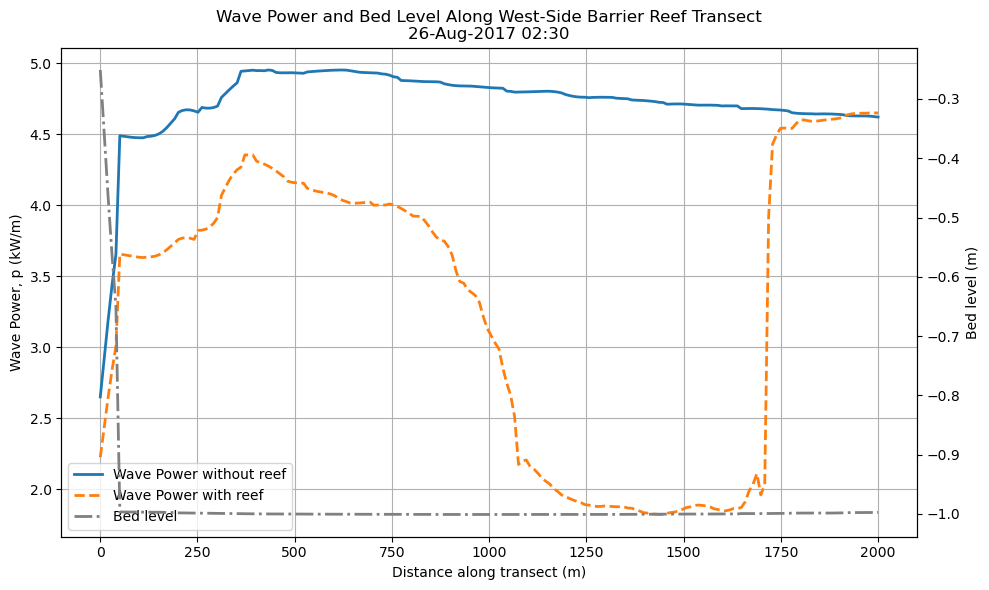

In [20]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# With reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_al_through_1.5m_height.sw - Result Files\small_scale_wave_result_with_barrier_reef_1.5m_v1.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# Bathymetry DFSU file
bathy_dfsu = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\existing_topo_bathy_port_lavaca.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 729827, 3174795
x2, y2 = 731549, 3175813

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Target time
# =========================
target_time = np.datetime64("2017-08-26T02:30:00")


# =========================
# Extract DFSU profile
# =========================
def extract_dfsu_profile(dfsu_file, item_name, target_time=None):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    da = ds[item_name]

    if "time" in da.dims and target_time is not None:
        time_index = np.argmin(np.abs(ds.time.values - target_time))
        selected_time = ds.time.values[time_index]
        da = da.isel(time=time_index)
    else:
        selected_time = None
        if "time" in da.dims:
            da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time


# =========================
# Extract bed level from bathymetry DFSU
# =========================
def extract_bed_from_dfsu(dfsu_file, item=0):
    dfs = mikeio.open(dfsu_file)

    print("Available bathymetry items:")
    for i, itm in enumerate(dfs.items):
        print(i, itm.name)

    ds = dfs.read(items=[item])
    da = ds[0]

    if "time" in da.dims:
        da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    bed_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return bed_profile


# =========================
# Extract variables
# =========================

hs_reef, time_reef = extract_dfsu_profile(
    dfsu_reef,
    "Wave power, p",
    target_time
)

hs_no_reef, time_no_reef = extract_dfsu_profile(
    dfsu_no_reef,
    "Wave power, p",
    target_time
)

bed_level = extract_bed_from_dfsu(
    bathy_dfsu,
    item=0
)

print("Selected timestep with reef:", time_reef)
print("Selected timestep without reef:", time_no_reef)


# =========================
# Plot
# =========================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary y-axis: Significant wave height
ax1.plot(
    distance,
    hs_no_reef,
    linewidth=2,
    label="Wave Power without reef"
)

ax1.plot(
    distance,
    hs_reef,
    linewidth=2,
    linestyle="--",
    label="Wave Power with reef"
)

ax1.set_xlabel("Distance along transect (m)")
ax1.set_ylabel("Wave Power, p (kW/m)")
ax1.grid(True)

# Secondary y-axis: Bed level
ax2 = ax1.twinx()

ax2.plot(
    distance,
    bed_level,
    linewidth=2,
    color="gray",
    linestyle="-.",
    label="Bed level"
)

ax2.set_ylabel("Bed level (m)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

plt.title(
    "Wave Power and Bed Level Along West-Side Barrier Reef Transect\n"
    "26-Aug-2017 02:30"
)

plt.tight_layout()
plt.show()

Available bathymetry items:
0 
Selected timestep with reef: 2017-08-26T02:30:00.000000000
Selected timestep without reef: 2017-08-26T02:30:00.000000000


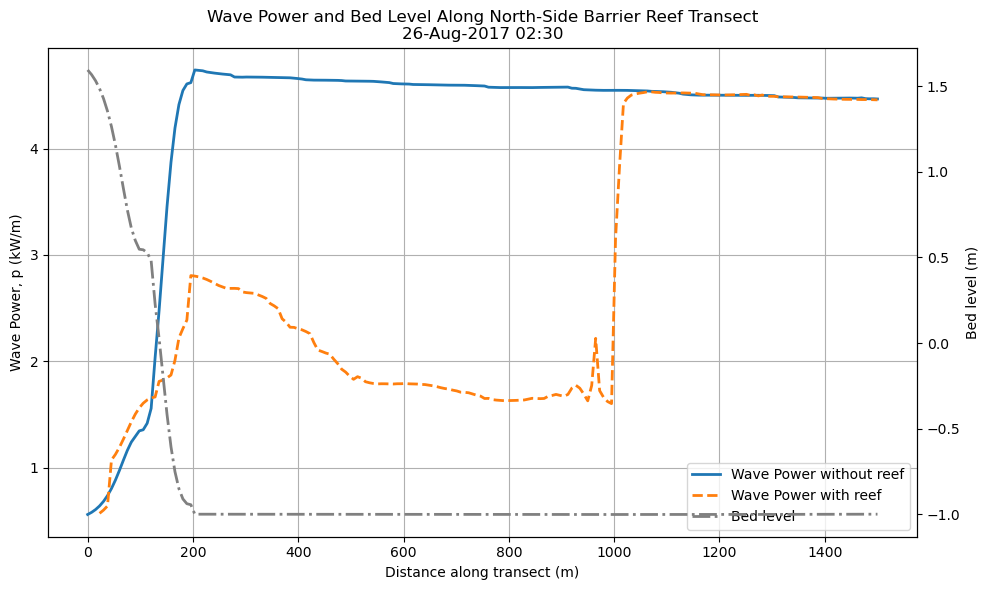

In [22]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# With reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Northside_barrier_reef_1.5m_v3.sw - Result Files\Northside_barrier_reef_1.5m_v3.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# Bathymetry DFSU file
bathy_dfsu = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\existing_topo_bathy_port_lavaca.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 732144, 3178938
x2, y2 = 732762, 3177571

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Target time
# =========================
target_time = np.datetime64("2017-08-26T02:30:00")


# =========================
# Extract DFSU profile
# =========================
def extract_dfsu_profile(dfsu_file, item_name, target_time=None):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    da = ds[item_name]

    if "time" in da.dims and target_time is not None:
        time_index = np.argmin(np.abs(ds.time.values - target_time))
        selected_time = ds.time.values[time_index]
        da = da.isel(time=time_index)
    else:
        selected_time = None
        if "time" in da.dims:
            da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time


# =========================
# Extract bed level from bathymetry DFSU
# =========================
def extract_bed_from_dfsu(dfsu_file, item=0):
    dfs = mikeio.open(dfsu_file)

    print("Available bathymetry items:")
    for i, itm in enumerate(dfs.items):
        print(i, itm.name)

    ds = dfs.read(items=[item])
    da = ds[0]

    if "time" in da.dims:
        da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    bed_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return bed_profile


# =========================
# Extract variables
# =========================

hs_reef, time_reef = extract_dfsu_profile(
    dfsu_reef,
    "Wave power, p",
    target_time
)

hs_no_reef, time_no_reef = extract_dfsu_profile(
    dfsu_no_reef,
    "Wave power, p",
    target_time
)

bed_level = extract_bed_from_dfsu(
    bathy_dfsu,
    item=0
)

print("Selected timestep with reef:", time_reef)
print("Selected timestep without reef:", time_no_reef)


# =========================
# Plot
# =========================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary y-axis: Significant wave height
ax1.plot(
    distance,
    hs_no_reef,
    linewidth=2,
    label="Wave Power without reef"
)

ax1.plot(
    distance,
    hs_reef,
    linewidth=2,
    linestyle="--",
    label="Wave Power with reef"
)

ax1.set_xlabel("Distance along transect (m)")
ax1.set_ylabel("Wave Power, p (kW/m)")
ax1.grid(True)

# Secondary y-axis: Bed level
ax2 = ax1.twinx()

ax2.plot(
    distance,
    bed_level,
    linewidth=2,
    color="gray",
    linestyle="-.",
    label="Bed level"
)

ax2.set_ylabel("Bed level (m)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

plt.title(
    "Wave Power and Bed Level Along North-Side Barrier Reef Transect\n"
    "26-Aug-2017 02:30"
)

plt.tight_layout()
plt.show()

Available bathymetry items:
0 
Selected timestep with reef: 2017-08-26T02:30:00.000000000
Selected timestep without reef: 2017-08-26T02:30:00.000000000


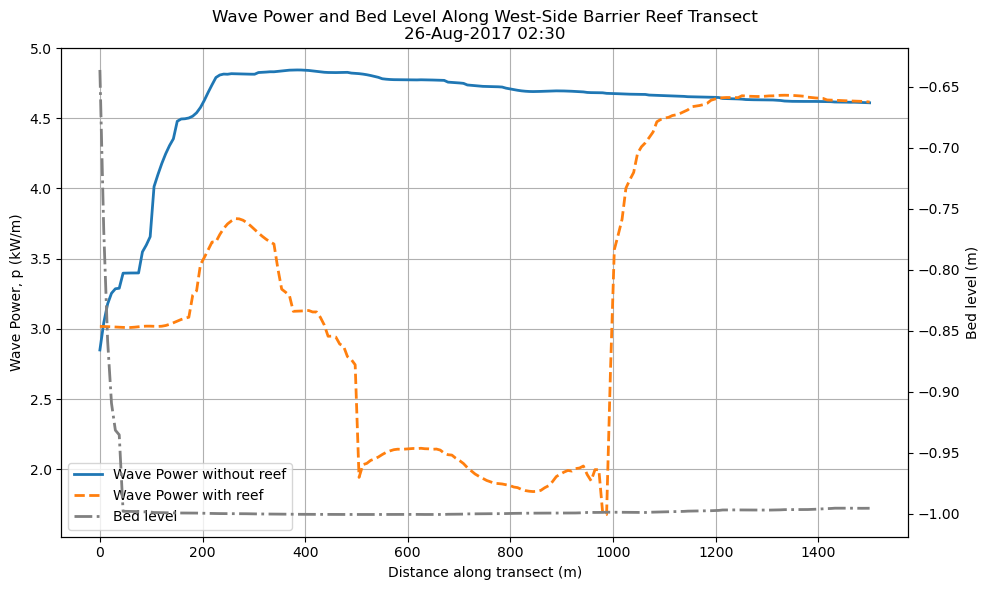

In [23]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# With reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_1.5m_v2.sw - Result Files\west_side_barrier_reef_1.5m_v2.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# Bathymetry DFSU file
bathy_dfsu = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\existing_topo_bathy_port_lavaca.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 730446, 3174401
x2, y2 = 731495, 3175473

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Target time
# =========================
target_time = np.datetime64("2017-08-26T02:30:00")


# =========================
# Extract DFSU profile
# =========================
def extract_dfsu_profile(dfsu_file, item_name, target_time=None):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    da = ds[item_name]

    if "time" in da.dims and target_time is not None:
        time_index = np.argmin(np.abs(ds.time.values - target_time))
        selected_time = ds.time.values[time_index]
        da = da.isel(time=time_index)
    else:
        selected_time = None
        if "time" in da.dims:
            da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time


# =========================
# Extract bed level from bathymetry DFSU
# =========================
def extract_bed_from_dfsu(dfsu_file, item=0):
    dfs = mikeio.open(dfsu_file)

    print("Available bathymetry items:")
    for i, itm in enumerate(dfs.items):
        print(i, itm.name)

    ds = dfs.read(items=[item])
    da = ds[0]

    if "time" in da.dims:
        da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    bed_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return bed_profile


# =========================
# Extract variables
# =========================

hs_reef, time_reef = extract_dfsu_profile(
    dfsu_reef,
    "Wave power, p",
    target_time
)

hs_no_reef, time_no_reef = extract_dfsu_profile(
    dfsu_no_reef,
    "Wave power, p",
    target_time
)

bed_level = extract_bed_from_dfsu(
    bathy_dfsu,
    item=0
)

print("Selected timestep with reef:", time_reef)
print("Selected timestep without reef:", time_no_reef)


# =========================
# Plot
# =========================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary y-axis: Significant wave height
ax1.plot(
    distance,
    hs_no_reef,
    linewidth=2,
    label="Wave Power without reef"
)

ax1.plot(
    distance,
    hs_reef,
    linewidth=2,
    linestyle="--",
    label="Wave Power with reef"
)

ax1.set_xlabel("Distance along transect (m)")
ax1.set_ylabel("Wave Power, p (kW/m)")
ax1.grid(True)

# Secondary y-axis: Bed level
ax2 = ax1.twinx()

ax2.plot(
    distance,
    bed_level,
    linewidth=2,
    color="gray",
    linestyle="-.",
    label="Bed level"
)

ax2.set_ylabel("Bed level (m)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

plt.title(
    "Wave Power and Bed Level Along West-Side Barrier Reef Transect\n"
    "26-Aug-2017 02:30"
)

plt.tight_layout()
plt.show()

Available bathymetry items:
0 
Selected timestep with reef: 2017-08-26T02:30:00.000000000
Selected timestep without reef: 2017-08-26T02:30:00.000000000


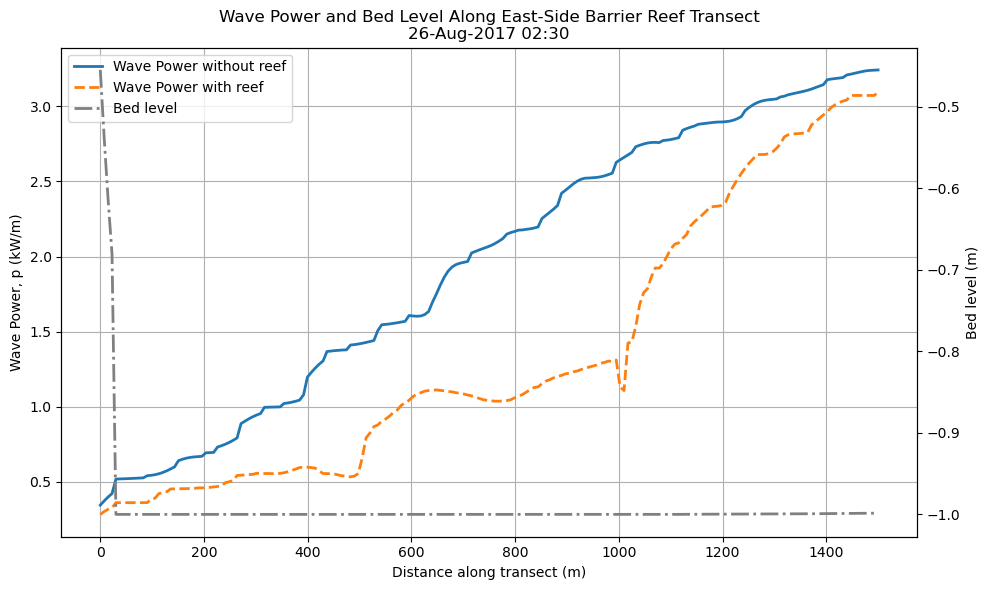

In [24]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# With reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef_1.5m_v2.sw - Result Files\east_side_reef_1.5m_v2.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# Bathymetry DFSU file
bathy_dfsu = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\existing_topo_bathy_port_lavaca.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 736662, 3177738
x2, y2 = 735243, 3177252

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Target time
# =========================
target_time = np.datetime64("2017-08-26T02:30:00")


# =========================
# Extract DFSU profile
# =========================
def extract_dfsu_profile(dfsu_file, item_name, target_time=None):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    da = ds[item_name]

    if "time" in da.dims and target_time is not None:
        time_index = np.argmin(np.abs(ds.time.values - target_time))
        selected_time = ds.time.values[time_index]
        da = da.isel(time=time_index)
    else:
        selected_time = None
        if "time" in da.dims:
            da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time


# =========================
# Extract bed level from bathymetry DFSU
# =========================
def extract_bed_from_dfsu(dfsu_file, item=0):
    dfs = mikeio.open(dfsu_file)

    print("Available bathymetry items:")
    for i, itm in enumerate(dfs.items):
        print(i, itm.name)

    ds = dfs.read(items=[item])
    da = ds[0]

    if "time" in da.dims:
        da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    bed_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return bed_profile


# =========================
# Extract variables
# =========================

hs_reef, time_reef = extract_dfsu_profile(
    dfsu_reef,
    "Wave power, p",
    target_time
)

hs_no_reef, time_no_reef = extract_dfsu_profile(
    dfsu_no_reef,
    "Wave power, p",
    target_time
)

bed_level = extract_bed_from_dfsu(
    bathy_dfsu,
    item=0
)

print("Selected timestep with reef:", time_reef)
print("Selected timestep without reef:", time_no_reef)


# =========================
# Plot
# =========================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary y-axis: Significant wave height
ax1.plot(
    distance,
    hs_no_reef,
    linewidth=2,
    label="Wave Power without reef"
)

ax1.plot(
    distance,
    hs_reef,
    linewidth=2,
    linestyle="--",
    label="Wave Power with reef"
)

ax1.set_xlabel("Distance along transect (m)")
ax1.set_ylabel("Wave Power, p (kW/m)")
ax1.grid(True)

# Secondary y-axis: Bed level
ax2 = ax1.twinx()

ax2.plot(
    distance,
    bed_level,
    linewidth=2,
    color="gray",
    linestyle="-.",
    label="Bed level"
)

ax2.set_ylabel("Bed level (m)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

plt.title(
    "Wave Power and Bed Level Along East-Side Barrier Reef Transect\n"
    "26-Aug-2017 02:30"
)

plt.tight_layout()
plt.show()

Available bathymetry items:
0 
Selected timestep with reef: 2017-08-26T02:30:00.000000000
Selected timestep without reef: 2017-08-26T02:30:00.000000000


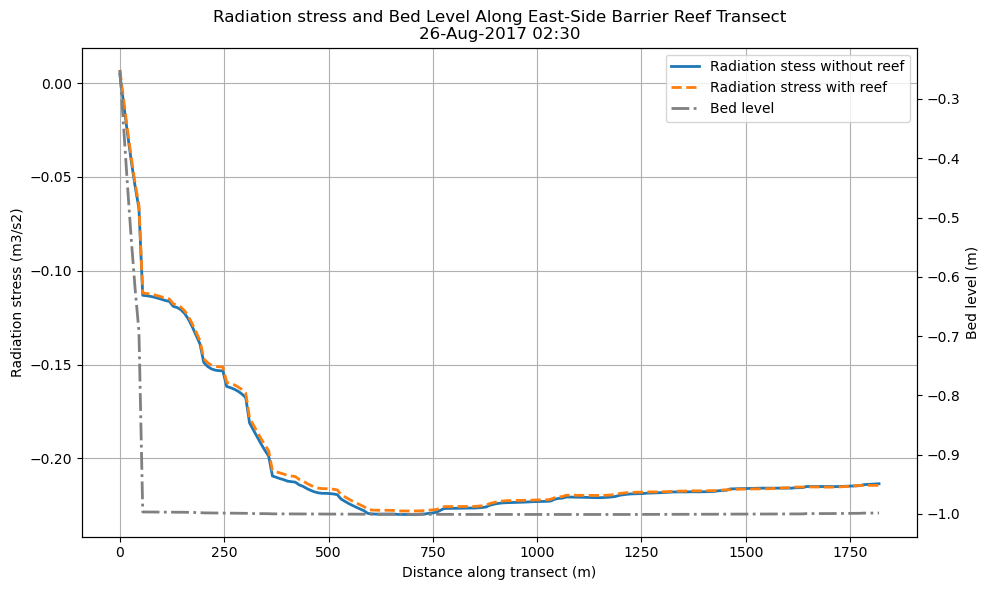

In [14]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# With reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef.sw - Result Files\east_side_reef.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# Bathymetry DFSU file
bathy_dfsu = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\existing_topo_bathy_port_lavaca.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Target time
# =========================
target_time = np.datetime64("2017-08-26T02:30:00")


# =========================
# Extract DFSU profile
# =========================
def extract_dfsu_profile(dfsu_file, item_name, target_time=None):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    da = ds[item_name]

    if "time" in da.dims and target_time is not None:
        time_index = np.argmin(np.abs(ds.time.values - target_time))
        selected_time = ds.time.values[time_index]
        da = da.isel(time=time_index)
    else:
        selected_time = None
        if "time" in da.dims:
            da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time


# =========================
# Extract bed level from bathymetry DFSU
# =========================
def extract_bed_from_dfsu(dfsu_file, item=0):
    dfs = mikeio.open(dfsu_file)

    print("Available bathymetry items:")
    for i, itm in enumerate(dfs.items):
        print(i, itm.name)

    ds = dfs.read(items=[item])
    da = ds[0]

    if "time" in da.dims:
        da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    bed_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return bed_profile


# =========================
# Extract variables
# =========================

hs_reef, time_reef = extract_dfsu_profile(
    dfsu_reef,
    "Rad. Stress, Sxy",
    target_time
)

hs_no_reef, time_no_reef = extract_dfsu_profile(
    dfsu_no_reef,
    "Rad. Stress, Sxy",
    target_time
)

bed_level = extract_bed_from_dfsu(
    bathy_dfsu,
    item=0
)

print("Selected timestep with reef:", time_reef)
print("Selected timestep without reef:", time_no_reef)


# =========================
# Plot
# =========================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary y-axis: Significant wave height
ax1.plot(
    distance,
    hs_no_reef,
    linewidth=2,
    label="Radiation stess without reef"
)

ax1.plot(
    distance,
    hs_reef,
    linewidth=2,
    linestyle="--",
    label="Radiation stress with reef"
)

ax1.set_xlabel("Distance along transect (m)")
ax1.set_ylabel("Radiation stress (m3/s2)")
ax1.grid(True)

# Secondary y-axis: Bed level
ax2 = ax1.twinx()

ax2.plot(
    distance,
    bed_level,
    linewidth=2,
    color="gray",
    linestyle="-.",
    label="Bed level"
)

ax2.set_ylabel("Bed level (m)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

plt.title(
    "Radiation stress and Bed Level Along East-Side Barrier Reef Transect\n"
    "26-Aug-2017 02:30"
)

plt.tight_layout()
plt.show()

Selected timestep with reef: 2017-08-26T02:30:00.000000000
Selected timestep without reef: 2017-08-26T02:30:00.000000000


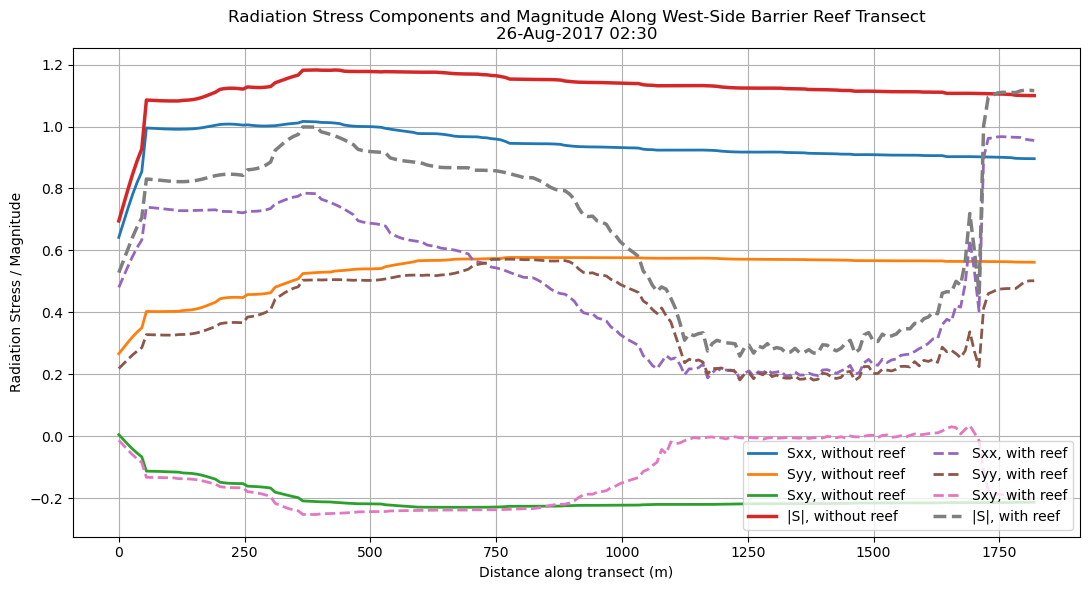

In [17]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# With reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Extract DFSU profile
# =========================
def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# =========================
# Extract radiation stress components
# =========================

# With reef
sxx_reef, time_reef = extract_profile(dfsu_reef, "Rad. Stress, Sxx")
syy_reef, _ = extract_profile(dfsu_reef, "Rad. Stress, Syy")
sxy_reef, _ = extract_profile(dfsu_reef, "Rad. Stress, Sxy")

# Without reef
sxx_no, time_no = extract_profile(dfsu_no_reef, "Rad. Stress, Sxx")
syy_no, _ = extract_profile(dfsu_no_reef, "Rad. Stress, Syy")
sxy_no, _ = extract_profile(dfsu_no_reef, "Rad. Stress, Sxy")

# =========================
# Calculate radiation stress magnitude
# |S| = sqrt(Sxx^2 + Syy^2 + 2*Sxy^2)
# =========================
s_mag_reef = np.sqrt(sxx_reef**2 + syy_reef**2 + 2 * sxy_reef**2)
s_mag_no = np.sqrt(sxx_no**2 + syy_no**2 + 2 * sxy_no**2)

print("Selected timestep with reef:", time_reef)
print("Selected timestep without reef:", time_no)

# =========================
# Plot all radiation stress components and magnitude
# =========================
plt.figure(figsize=(11, 6))

# Without reef
plt.plot(distance, sxx_no, linewidth=2, label="Sxx, without reef")
plt.plot(distance, syy_no, linewidth=2, label="Syy, without reef")
plt.plot(distance, sxy_no, linewidth=2, label="Sxy, without reef")
plt.plot(distance, s_mag_no, linewidth=2.5, label="|S|, without reef")

# With reef
plt.plot(distance, sxx_reef, linewidth=2, linestyle="--", label="Sxx, with reef")
plt.plot(distance, syy_reef, linewidth=2, linestyle="--", label="Syy, with reef")
plt.plot(distance, sxy_reef, linewidth=2, linestyle="--", label="Sxy, with reef")
plt.plot(distance, s_mag_reef, linewidth=2.5, linestyle="--", label="|S|, with reef")

plt.xlabel("Distance along transect (m)")
plt.ylabel("Radiation Stress / Magnitude")
plt.title("Radiation Stress Components and Magnitude Along West-Side Barrier Reef Transect\n26-Aug-2017 02:30")
plt.grid(True)
plt.legend(frameon=True, ncol=2)

plt.tight_layout()
plt.show()

Selected timestep with reef: 2017-08-26T02:30:00.000000000
Selected timestep without reef: 2017-08-26T02:30:00.000000000


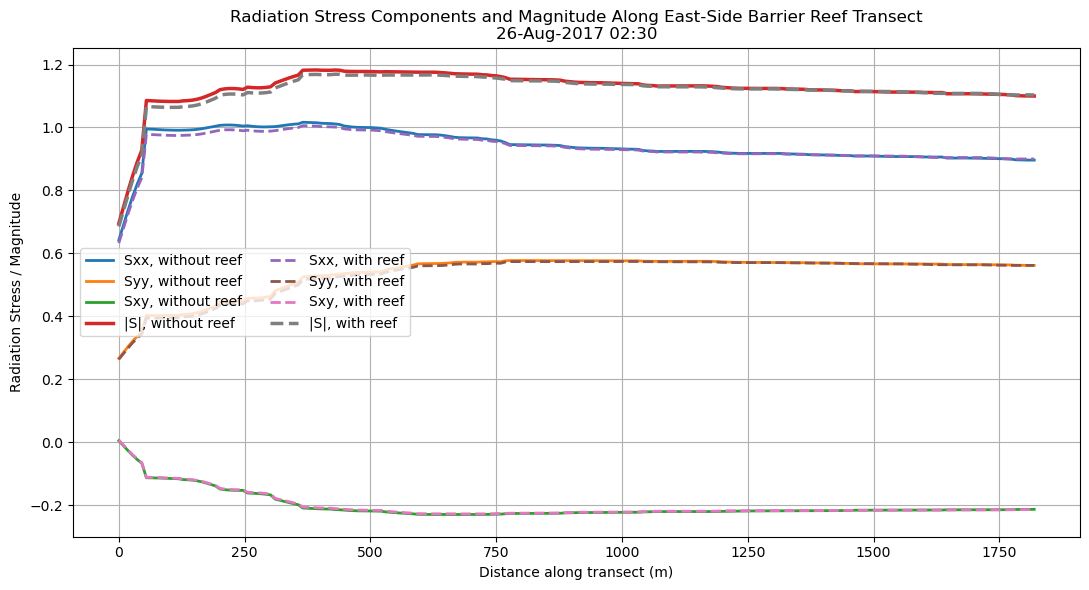

In [18]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# With reef condition
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef.sw - Result Files\east_side_reef.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

target_time = np.datetime64("2017-08-26T02:30:00")

# =========================
# Extract DFSU profile
# =========================
def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# =========================
# Extract radiation stress components
# =========================

# With reef
sxx_reef, time_reef = extract_profile(dfsu_reef, "Rad. Stress, Sxx")
syy_reef, _ = extract_profile(dfsu_reef, "Rad. Stress, Syy")
sxy_reef, _ = extract_profile(dfsu_reef, "Rad. Stress, Sxy")

# Without reef
sxx_no, time_no = extract_profile(dfsu_no_reef, "Rad. Stress, Sxx")
syy_no, _ = extract_profile(dfsu_no_reef, "Rad. Stress, Syy")
sxy_no, _ = extract_profile(dfsu_no_reef, "Rad. Stress, Sxy")

# =========================
# Calculate radiation stress magnitude
# |S| = sqrt(Sxx^2 + Syy^2 + 2*Sxy^2)
# =========================
s_mag_reef = np.sqrt(sxx_reef**2 + syy_reef**2 + 2 * sxy_reef**2)
s_mag_no = np.sqrt(sxx_no**2 + syy_no**2 + 2 * sxy_no**2)

print("Selected timestep with reef:", time_reef)
print("Selected timestep without reef:", time_no)

# =========================
# Plot all radiation stress components and magnitude
# =========================
plt.figure(figsize=(11, 6))

# Without reef
plt.plot(distance, sxx_no, linewidth=2, label="Sxx, without reef")
plt.plot(distance, syy_no, linewidth=2, label="Syy, without reef")
plt.plot(distance, sxy_no, linewidth=2, label="Sxy, without reef")
plt.plot(distance, s_mag_no, linewidth=2.5, label="|S|, without reef")

# With reef
plt.plot(distance, sxx_reef, linewidth=2, linestyle="--", label="Sxx, with reef")
plt.plot(distance, syy_reef, linewidth=2, linestyle="--", label="Syy, with reef")
plt.plot(distance, sxy_reef, linewidth=2, linestyle="--", label="Sxy, with reef")
plt.plot(distance, s_mag_reef, linewidth=2.5, linestyle="--", label="|S|, with reef")

plt.xlabel("Distance along transect (m)")
plt.ylabel("Radiation Stress / Magnitude")
plt.title("Radiation Stress Components and Magnitude Along East-Side Barrier Reef Transect\n26-Aug-2017 02:30")
plt.grid(True)
plt.legend(frameon=True, ncol=2)

plt.tight_layout()
plt.show()